## 4장 1강: 파이토치 기초 및 심층 신경망

### 6. 파이토치 기반 패션 이미지 다층 모델 실습
#### 6.1 데이터 준비 및 전처리
실습에 필요한 도구 불러오기 및 설정

In [1]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else 
    "cpu"
)

print(f"현재 사용 중인 연산 디바이스: {device}")

현재 사용 중인 연산 디바이스: cpu


Fashion MNIST 데이터 불러오기

In [2]:
# Fashion MNIST 28 X 28(2차원) (0~255) -> 표준 점수 -> 특성은 1차원으로 변환 
# 60,000 -> 훈련 데이터는 50,000 장, 검증 (10,0000)

# 훈련 데이터 셋
raw_train_data = datasets.FashionMNIST(
    root="data", train=True, download=True, transform=ToTensor()
)

# 테스트 데이터 셋
test_data = datasets.FashionMNIST(
    root="data", train=False, download=True, transform=ToTensor()
)

In [3]:
# 검증 데이터 셋 분리
train_size = 50000
val_size = 10000

train_data, val_data = random_split(
    raw_train_data, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("훈련 세트:", len(train_data))
print("검증 세트:", len(val_data))
print("테스트 세트:", len(test_data))

훈련 세트: 50000
검증 세트: 10000
테스트 세트: 10000


In [4]:
# 데이터 세트별 DataLoader 생성
# batch_size ->1 에포크에서 전 데이터셋을 32개의 배치로 분할 -> 미니배치 경사하강법
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [7]:
train_data[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1529, 0.2353, 0.2000,
           0.2235, 0.1961, 0.2157, 0.2078, 0.1961, 0.1922, 0.1647, 0.1725,
           0.1804, 0.1843, 0.2353, 0.0431],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0078, 0.0000, 0.5216, 0.6196, 0.5922,
           0.7529, 0.7725, 0.8118, 0.7882, 

### 6.2 모델 설계

다층 퍼셉트론(MLP) 모델 클래스 정의

In [8]:
import torch.nn as nn
import torch.optim as optim 

class AdvancedFashionClassifier(nn.Module):

    # 사용할 층(layer)를 정의
    def __init__(self):
        super().__init__()

        # (28, 28) -> 특성은 1차원으로 변경 (784,)
        # nn.Flatten() -> 2차원 텐서 -> 1차원 텐서 - 입력층
        self.flatten = nn.Flatten()

        # 은닉층 (784 -> 128)
        self.hidden_layer = nn.Linear(784, 128)

        # 활성화 함수(ReLU)
        self.relu = nn.ReLU()

        # Dropout - 0~1, 0.1~0.5
        self.dropout = nn.Dropout(p=0.2)

        # 출력층 128 -> 10
        self.output_layer = nn.Linear(128, 10)

    # 순전파(Feed Forward)
    def forward(self, x):
        out = self.flatten(x) # 28 X 27 -> 784 # 입력층 처리
        out = self.hidden_layer(out) # 784 -> 128 # 은닉층 처리
        out = self.relu(out) # 활성화 함수 통과(선형적 -> 비선형적)
        out = self.dropout(out) # 훈련시에만 피요, 과대적합 방지 (128,)
        out = self.output_layer(out) # 출력층 128 -> 10

        return out




모델 인스턴스 생성 및 연산 디바이스(GPU/MPS/CPU)로 할당

In [9]:
model = AdvancedFashionClassifier().to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"학습 가능한 총 모델 파라미터 갯수: {total_params:,}개")

학습 가능한 총 모델 파라미터 갯수: 101,770개


손실 함수 및 옵티마이저 정의

In [10]:
# 손실 함수
criterion = nn.CrossEntropyLoss()

# 옵티마이저
optimizer = optim.Adam(model.parameters(), lr=0.005)

### 6.3 조기 종료 학습 및 검증 루프

In [11]:
epochs = 20 # 최대 에포크
patience = 3 # 검증 로스가 더이상 떨어지지 않는 횟수, 3회 이상이면 학습 종료(조기종료)
patience_count = 0
best_val_loss = float('inf')

train_losses = []
val_losses = []

for epoch in range(epochs):
    running_loss = 0.0 #한 에포크(각 배치의 모든 손실)의 손실
    model.train() # 학습 모드 (학습에 필요한 것들 활성 - 예) Dropout )

    for images, labels in train_loader: # 미니배치(32개씩)
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # 이전 그래디언트(기울기)를 초기화

        # 순방향 예측 
        outputs = model(images)

        # 손실 계산
        loss = criterion(outputs, labels)

        # 오차 역전파 수행  - 그래디언트(기울기)
        loss.backward()

        # 옵티마이저를 통한 가중치 업데이트
        optimizer.step()

        running_loss += loss.item() # 배치마다의 로스를 기록(1에포크)

    epoch_loss = running_loss / len(train_loader) # 1에포크 로스(배치 로스의 평균)
    train_losses.append(epoch_loss)

    # 검증 모드
    model.eval() # 평가시에는 학습시에만 필요한 부분이 배제, Dropout 배제
    val_loss = 0.0 

    with torch.no_grad(): # 검증시에는 그래디언트를 구하지 않는다. 학습 관련 연산을 하지 않음
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            # 검증 예측(순전파)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    epoch_val_loss = val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1}/{epochs} | 훈련 loss: {epoch_loss:.4f} | 검증 loss: {val_loss:.4f}")

    # 조기 종료 
    if epoch_val_loss < best_val_loss:
        # 기존 검증 로스보다 개선이 되었다!
        best_val_loss = epoch_val_loss
        patience_count = 0

        # 손실이 개선된 모델을 저장
        torch.save(model.state_dict(), "best_fashion_model.pth")

    else: # 기존 검증 로스보다 개선이 안되었다!
        patience_count += 1
        print(f"== 검증 손실 미개선: {patience_count}/{patience} ==")

        # patience 한계를 초과하면 학습을 중단(조기종료)
        if patience_count >= patience:
            print(f"조기 종료:{epoch+1}에포크에서 학습 종료...")
            break



Epoch 1/20 | 훈련 loss: 0.5673 | 검증 loss: 140.3803
Epoch 2/20 | 훈련 loss: 0.4636 | 검증 loss: 123.0982
Epoch 3/20 | 훈련 loss: 0.4433 | 검증 loss: 130.7437
== 검증 손실 미개선: 1/3 ==
Epoch 4/20 | 훈련 loss: 0.4202 | 검증 loss: 119.1668
Epoch 5/20 | 훈련 loss: 0.4093 | 검증 loss: 120.3252
== 검증 손실 미개선: 1/3 ==
Epoch 6/20 | 훈련 loss: 0.4023 | 검증 loss: 121.8476
== 검증 손실 미개선: 2/3 ==
Epoch 7/20 | 훈련 loss: 0.3937 | 검증 loss: 124.7715
== 검증 손실 미개선: 3/3 ==
조기 종료:7에포크에서 학습 종료...


In [12]:
val_losses[:5]

[0.44849930065698895,
 0.39328498969348474,
 0.4177114034470278,
 0.38072451965782206,
 0.3844255235629341]

### 6.4 최종 테스트셋 기반 정확도 측정 및 시각화

In [15]:
# 가장 좋은 가중치지의 모델을 불러오기
model.load_state_dict(torch.load("best_fashion_model.pth"))
model.to(device)

# 테스트 셋으로 평가
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        print("predicted:", predicted)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = correct / total * 100
print(f"테스트 세트 정확도: {test_accuracy:.4f}%")

predicted: tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 7, 3, 4, 1, 2, 4, 8, 0, 4, 7, 7, 7,
        1, 2, 6, 0, 9, 4, 8, 8])
predicted: tensor([3, 3, 8, 0, 7, 5, 7, 9, 0, 1, 0, 7, 6, 7, 2, 1, 4, 2, 4, 2, 5, 8, 2, 2,
        8, 4, 8, 0, 7, 7, 8, 5])
predicted: tensor([1, 1, 2, 4, 7, 8, 7, 0, 2, 6, 4, 3, 1, 2, 8, 4, 1, 8, 5, 9, 5, 0, 3, 2,
        0, 2, 5, 3, 6, 7, 1, 8])
predicted: tensor([0, 1, 2, 2, 3, 6, 7, 6, 7, 8, 5, 9, 9, 4, 2, 5, 7, 0, 5, 2, 8, 4, 7, 8,
        0, 0, 9, 9, 3, 0, 8, 2])
predicted: tensor([1, 5, 4, 1, 9, 1, 8, 4, 2, 1, 2, 5, 1, 6, 0, 0, 1, 6, 1, 3, 2, 2, 3, 2,
        1, 3, 5, 6, 4, 7, 9, 3])
predicted: tensor([7, 2, 3, 9, 0, 9, 4, 7, 4, 2, 6, 5, 2, 1, 2, 1, 3, 0, 9, 1, 0, 9, 3, 6,
        7, 9, 9, 4, 4, 7, 1, 2])
predicted: tensor([3, 2, 3, 2, 8, 3, 6, 1, 1, 0, 2, 9, 2, 4, 0, 7, 9, 8, 4, 1, 8, 4, 1, 3,
        1, 6, 7, 4, 8, 5, 2, 0])
predicted: tensor([7, 7, 6, 6, 7, 0, 7, 8, 9, 2, 9, 0, 5, 1, 4, 2, 5, 2, 9, 2, 2, 8, 6, 2,
        2, 4, 9, 7, 6, 5, 5, 4])
predicte

c:\Users\yonggyo\Documents\ax_study\04_MACHINE_LEARNING\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yonggyo\Documents\ax_study\04_MACHINE_LEARNING\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yonggyo\Documents\ax_study\04_MACHINE_LEARNING\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yonggyo\Documents\ax_study\04_MACHINE_LEARNING\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yonggyo\Documents\ax_study\04_MACHIN

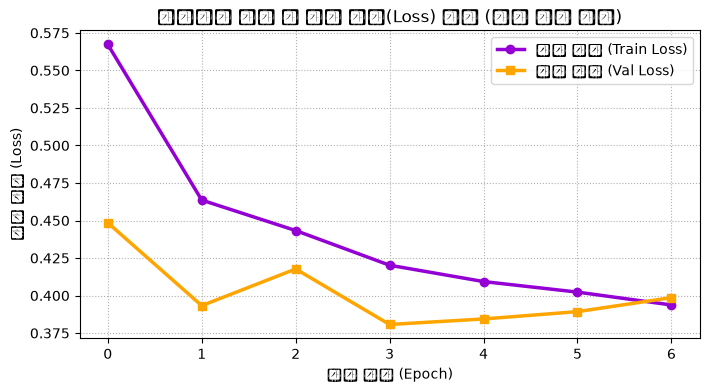

In [16]:
# 에포크별 훈련 및 검증 손실 곡선 시각화
plt.figure(figsize=(8, 4))
plt.plot(train_losses, marker='o', color='darkviolet', linewidth=2.5, label='훈련 손실 (Train Loss)')
plt.plot(val_losses, marker='s', color='orange', linewidth=2.5, label='검증 손실 (Val Loss)')
plt.title("에포크별 훈련 및 검증 손실(Loss) 추이 (조기 종료 적용)")
plt.xlabel("학습 횟수 (Epoch)")
plt.ylabel("손실 크기 (Loss)")
plt.legend()
plt.grid(True, linestyle=':')
plt.show()